# IMSE 586 Project

In [2]:
import numpy as np
import pandas as pd

In [3]:
yahoo = pd.read_csv("./data/yahoo_stock.csv")
yahoo

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107
...,...,...,...,...,...,...,...
1820,2020-11-16,3628.510010,3600.159912,3600.159912,3626.909912,5.281980e+09,3626.909912
1821,2020-11-17,3623.110107,3588.679932,3610.310059,3609.530029,4.799570e+09,3609.530029
1822,2020-11-18,3619.090088,3567.330078,3612.090088,3567.790039,5.274450e+09,3567.790039
1823,2020-11-19,3585.219971,3543.840088,3559.409912,3581.870117,4.347200e+09,3581.870117


In [4]:
yahoo.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


## DATA PREPROCESSING AND EXPLORATION.

In [49]:
# 1. Convert 'Date' column to datetime format and set as index
yahoo['Date'] = pd.to_datetime(yahoo['Date'])
yahoo.set_index('Date', inplace=True)

### Handling missing values

In [50]:
yahoo.isnull().sum()
yahoo.ffill(inplace=True)

In [51]:
yahoo.bfill(inplace=True)

In [52]:
yahoo.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1825 entries, 2015-11-23 to 2020-11-20
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       1825 non-null   float64
 1   Low        1825 non-null   float64
 2   Open       1825 non-null   float64
 3   Close      1825 non-null   float64
 4   Volume     1825 non-null   float64
 5   Adj Close  1825 non-null   float64
dtypes: float64(6)
memory usage: 99.8 KB


### Creating a column which gives info abt the Moving average of 20 & 50 days.

In [53]:
# Simple Moving Average (SMA) - 20-day and 50-day
yahoo['SMA_20'] = yahoo['Close'].rolling(window=20).mean()
yahoo['SMA_50'] = yahoo['Close'].rolling(window=50).mean()

In [54]:
# Calculate price differences
delta = yahoo['Close'].diff()

# Calculate gains and losses
gain = delta.clip(lower=0).rolling(window=14).mean()
loss = -delta.clip(upper=0).rolling(window=14).mean()

# Calculate RSI
yahoo['RSI'] = 100 - (100 / (1 + gain / loss))

In [55]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Apply normalization and add results as new columns
normalized_data = scaler.fit_transform(yahoo[['Close', 'Volume']])
yahoo[['Close_Norm', 'Volume_Norm']] = normalized_data

In [56]:
yahoo.tail()

,High,Low,Open,Close,Volume,Adj Close,SMA_20,SMA_50,RSI,Close_Norm,Volume_Norm
Date,,,,,,,,,,,
2020-11-16,3628.510010,3600.159912,3600.159912,3626.909912,5.281980e+09,3626.909912,3457.034460,3442.011572,89.590700,1.000000,0.514373
2020-11-17,3623.110107,3588.679932,3610.310059,3609.530029,4.799570e+09,3609.530029,3473.959460,3447.170171,83.534746,0.990333,0.452112
2020-11-18,3619.090088,3567.330078,3612.090088,3567.790039,5.274450e+09,3567.790039,3486.843457,3451.816572,69.080903,0.967116,0.513401
2020-11-19,3585.219971,3543.840088,3559.409912,3581.870117,4.347200e+09,3581.870117,3502.438965,3456.193975,63.084466,0.974948,0.393728
2020-11-20,3581.229980,3556.850098,3579.310059,3557.540039,2.236662e+09,3557.540039,3516.817969,3459.728774,58.118441,0.961415,0.121335


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
yahoo.reset_index(inplace=True)

In [59]:
yahoo['Date'] = pd.to_datetime(yahoo['Date'])

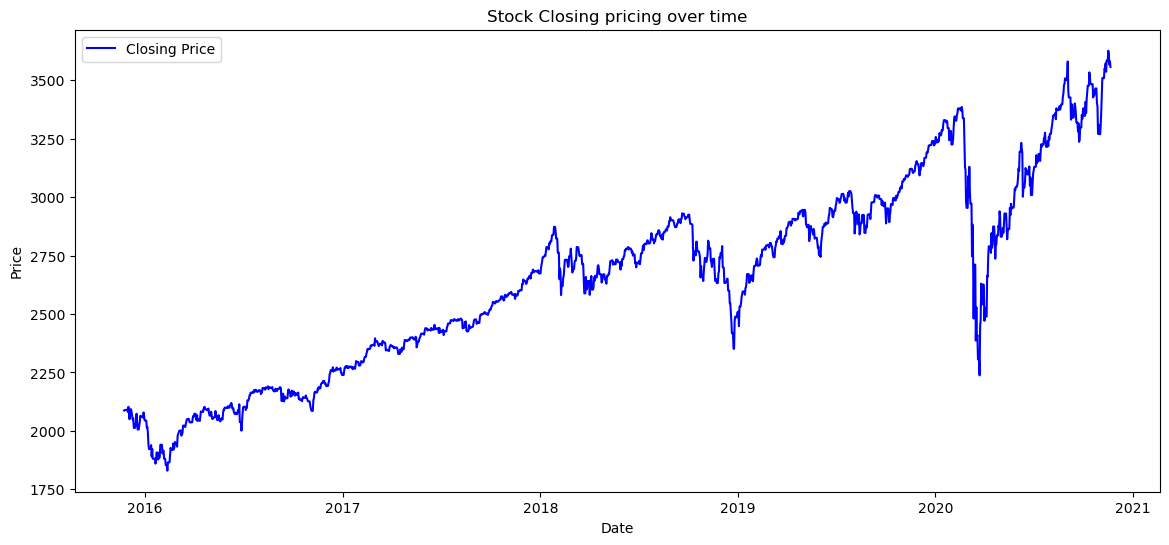

In [60]:
# Closing price over time.
plt.figure(figsize=(14,6))
plt.plot(yahoo['Date'], yahoo['Close'], label='Closing Price', color='blue')
plt.title('Stock Closing pricing over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

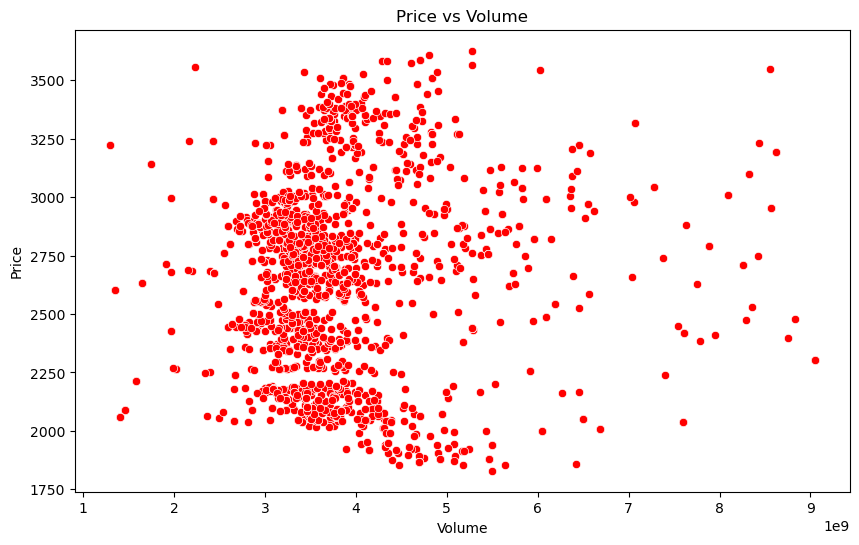

In [61]:
# Volume and price relationship.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=yahoo, x='Volume', y='Close', color='red')
plt.title('Price vs Volume')
plt.xlabel('Volume')
plt.ylabel('Price')
plt.show()

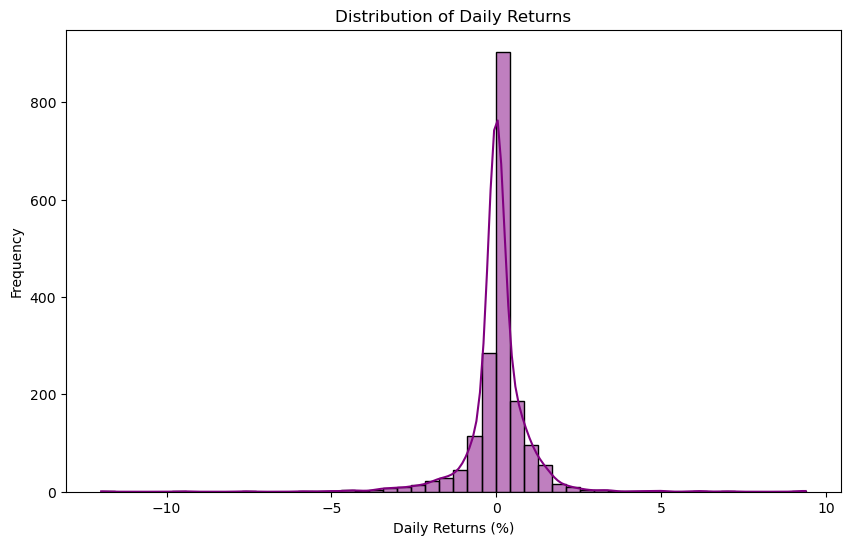

In [62]:
yahoo['Daily_Returns'] = yahoo['Close'].pct_change() * 100  # Percentage change
plt.figure(figsize=(10, 6))
sns.histplot(yahoo['Daily_Returns'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Returns (%)')
plt.ylabel('Frequency')
plt.show()

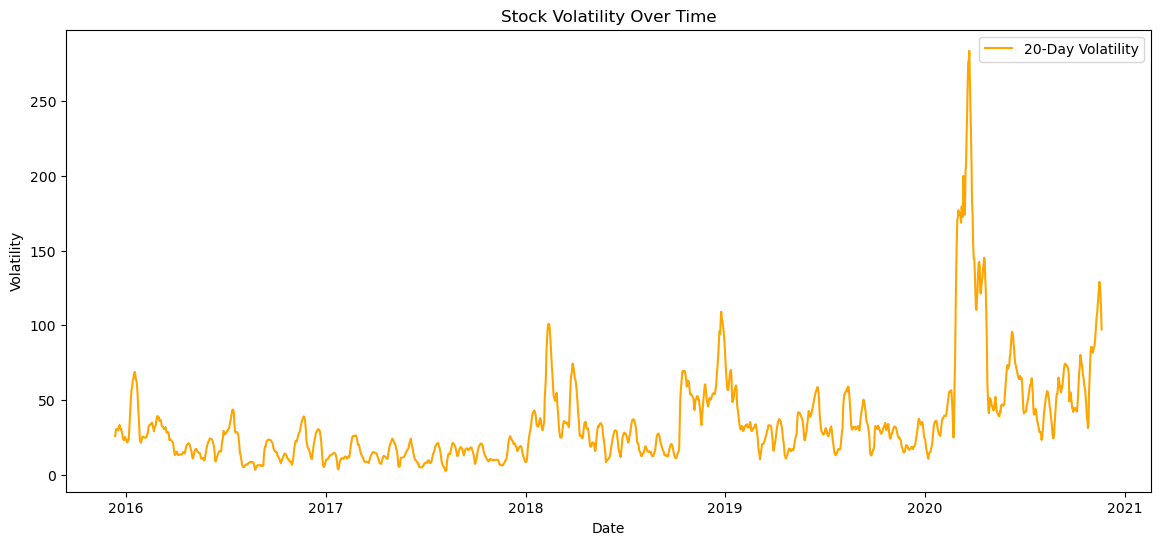

In [63]:
yahoo['Volatility'] = yahoo['Close'].rolling(window=20).std()
plt.figure(figsize=(14, 6))
plt.plot(yahoo['Date'], yahoo['Volatility'], label='20-Day Volatility', color='orange')
plt.title('Stock Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

### ARIMA MODEL

In [64]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

In [65]:
# Assuming your dataset is loaded into a DataFrame named 'yahoo'

# Set 'Date' as the index
yahoo.set_index('Date', inplace=True)

# Extract the 'Close' column as the target series for ARIMA
time_series = yahoo['Close']


In [66]:
# Function to check stationarity
def check_stationarity(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] <= 0.05:
        print("The series is stationary.")
    else:
        print("The series is non-stationary.")

# Check stationarity of the 'Close' series
check_stationarity(time_series)


ADF Statistic: -0.8703973870161532
p-value: 0.7975646340657438
The series is non-stationary.


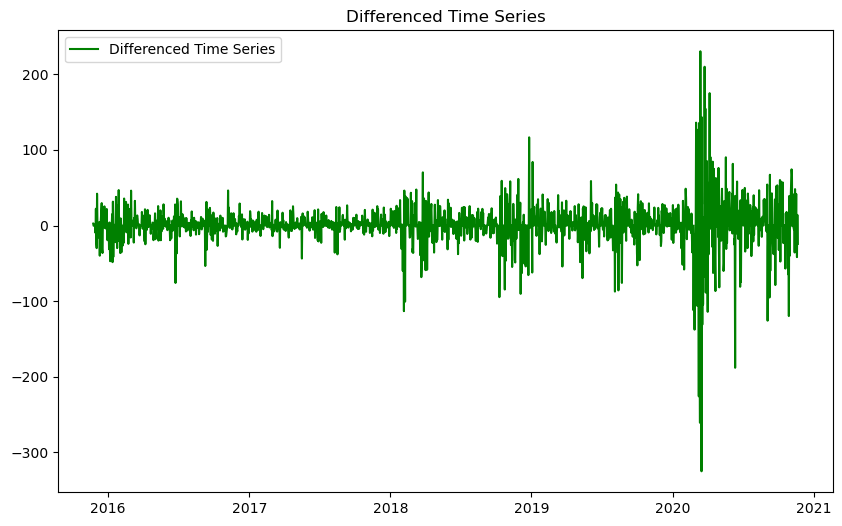

ADF Statistic: -8.522187682825956
p-value: 1.0930862670334438e-13
The series is stationary.


In [67]:
# Apply first-order differencing to make the data stationary
time_series_diff = time_series.diff().dropna()

# Plot the differenced series
plt.figure(figsize=(10, 6))
plt.plot(time_series_diff, label='Differenced Time Series', color='green')
plt.title('Differenced Time Series')
plt.legend()
plt.show()

# Re-check stationarity
check_stationarity(time_series_diff)


<Figure size 1200x600 with 0 Axes>

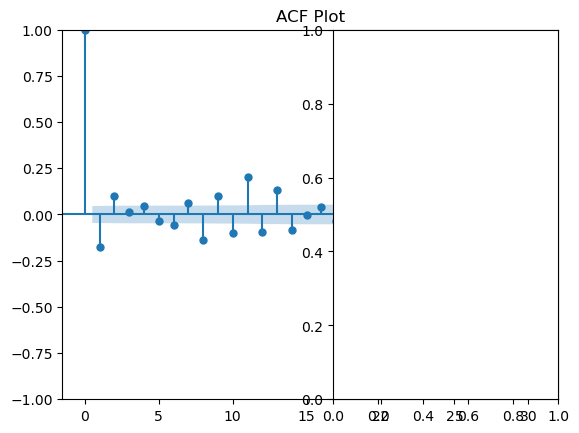

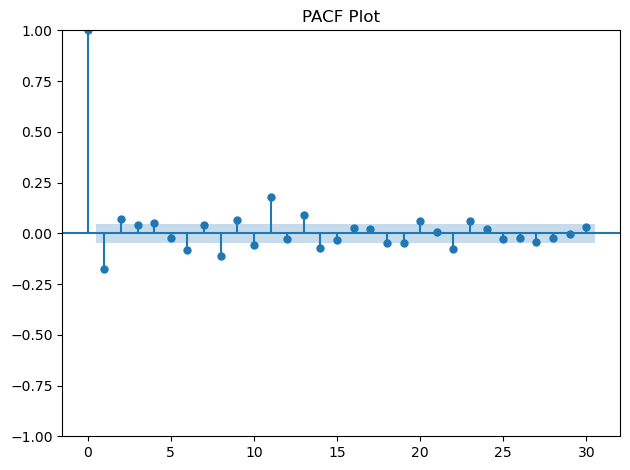

In [68]:
# ACF and PACF plots
plt.figure(figsize=(12, 6))
plot_acf(time_series_diff, lags=30)
plt.title('ACF Plot')
plt.subplot(122)
plot_pacf(time_series_diff, lags=30)
plt.title('PACF Plot')
plt.tight_layout()
plt.show()


In [69]:
# Fit the ARIMA model (replace p, d, q with chosen values)
p, d, q = 1, 1, 1  # Example parameters
model = ARIMA(time_series, order=(p, d, q))
fitted_model = model.fit()

# Print the model summary
print(fitted_model.summary())


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1825
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -8595.892
Date:                Mon, 09 Dec 2024   AIC                          17197.784
Time:                        18:51:09   BIC                          17214.310
Sample:                    11-23-2015   HQIC                         17203.880
                         - 11-20-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4444      0.033    -13.400      0.000      -0.509      -0.379
ma.L1          0.2759      0.036      7.707      0.000       0.206       0.346
sigma2       725.8924      6.074    119.514      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


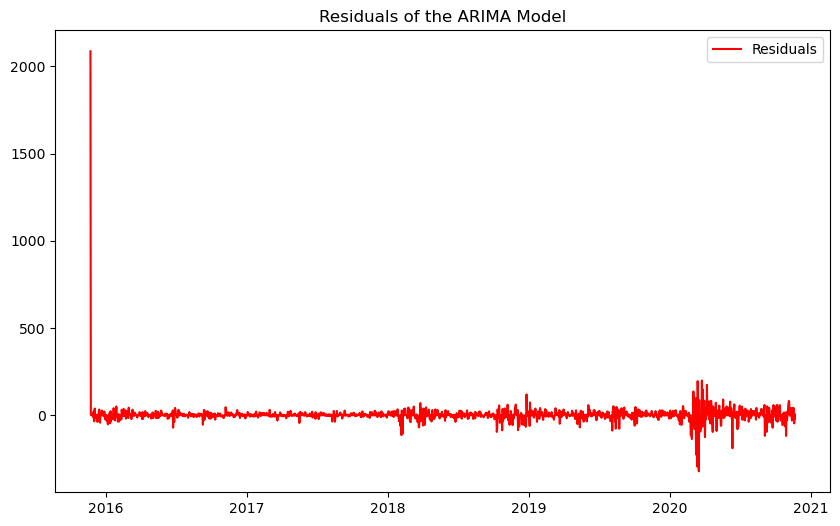

count    1825.000000
mean        2.058099
std        55.755297
min      -321.203503
25%        -3.481780
50%         0.304813
75%         7.898749
max      2086.590088
dtype: float64


In [70]:
# Plot residuals
residuals = fitted_model.resid
plt.figure(figsize=(10, 6))
plt.plot(residuals, label='Residuals', color='red')
plt.title('Residuals of the ARIMA Model')
plt.legend()
plt.show()

# Check residual statistics
print(residuals.describe())


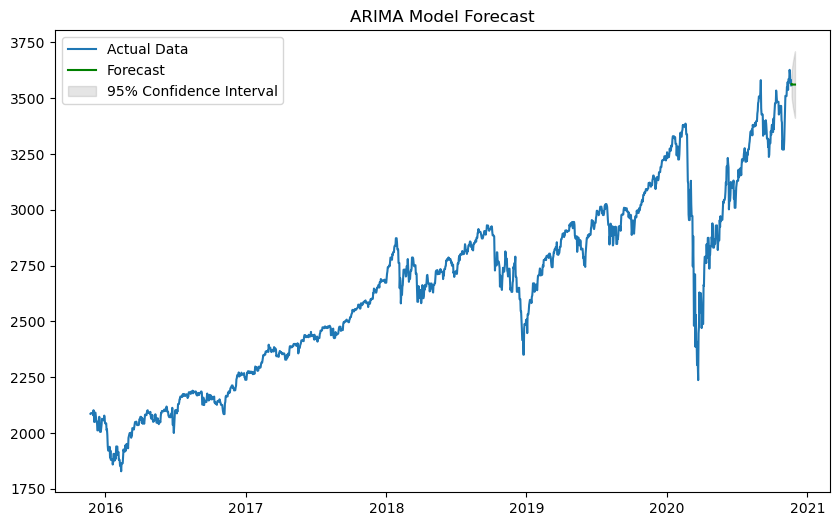

In [71]:
# Forecast future values using get_forecast
forecast_steps = 10
forecast_result = fitted_model.get_forecast(steps=forecast_steps)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

# Plot actual data and forecast
plt.figure(figsize=(10, 6))
plt.plot(time_series, label='Actual Data')
plt.plot(pd.date_range(time_series.index[-1], periods=forecast_steps + 1, freq='D')[1:], forecast, label='Forecast', color='green')
plt.fill_between(pd.date_range(time_series.index[-1], periods=forecast_steps + 1, freq='D')[1:], conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='k', alpha=0.1, label='95% Confidence Interval')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()


In [72]:
# Define the training and testing data
split_ratio = 0.8  # 80% for training, 20% for testing
split_index = int(len(time_series) * split_ratio)

train_data = time_series[:split_index]
test_data = time_series[split_index:]


In [73]:
# Fit ARIMA on training data
model = ARIMA(train_data, order=(p, d, q))  # Replace (p, d, q) with your parameters
fitted_model = model.fit()


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [74]:
# Forecast for the length of the test data
forecast_result = fitted_model.get_forecast(steps=len(test_data))
forecast = forecast_result.predicted_mean


In [75]:
# Calculate RMSE
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test_data, forecast))
print(f'Root Mean Square Error (RMSE): {rmse}')


Root Mean Square Error (RMSE): 278.4383066181459


In [76]:
import pickle

# Save the model
with open('arima_model.pkl', 'wb') as f:
    pickle.dump(fitted_model, f)


Root Mean Square Error (RMSE): 278.4383066181459


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


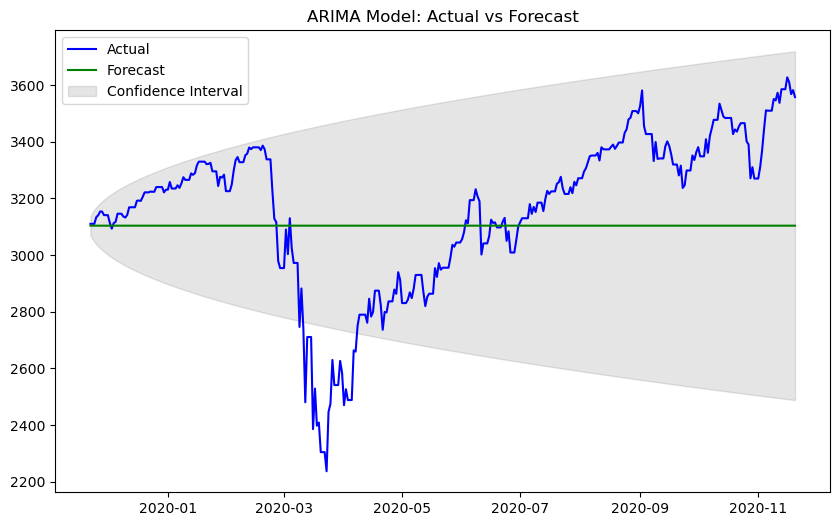

In [77]:
# Split dataset
split_ratio = 0.8
split_index = int(len(time_series) * split_ratio)
train_data = time_series[:split_index]
test_data = time_series[split_index:]

# Fit ARIMA on training data
model = ARIMA(train_data, order=(1, 1, 1))  # Example: (p=1, d=1, q=1)
fitted_model = model.fit()

# Forecast on test data
forecast_result = fitted_model.get_forecast(steps=len(test_data))
forecast = forecast_result.predicted_mean

# Compute RMSE
rmse = np.sqrt(mean_squared_error(test_data, forecast))
print(f'Root Mean Square Error (RMSE): {rmse}')

# Plot actual vs forecast
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data, label='Actual', color='blue')
plt.plot(test_data.index, forecast, label='Forecast', color='green')
plt.fill_between(test_data.index, 
                 forecast_result.conf_int()['lower Close'], 
                 forecast_result.conf_int()['upper Close'], 
                 color='k', alpha=0.1, label='Confidence Interval')
plt.title('ARIMA Model: Actual vs Forecast')
plt.legend()
plt.show()


### LSTM EARLY STOPING

In [79]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Example Data
X_train, y_train = np.random.rand(100, 10, 1), np.random.rand(100)
X_val, y_val = np.random.rand(20, 10, 1), np.random.rand(20)

# Define LSTM Model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# Hyperparameters
epochs = 100
patience = 5
best_val_loss = np.inf
wait = 0

# Custom Training Loop with Early Stopping
for epoch in range(epochs):
    # Train for one epoch
    model.fit(X_train, y_train, epochs=1, batch_size=32, verbose=1, validation_data=(X_val, y_val))
    
    # Calculate validation loss
    val_loss = model.evaluate(X_val, y_val, verbose=0)
    print(f"Epoch {epoch + 1}/{epochs}, Validation Loss: {val_loss}")
    
    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0  # Reset patience counter
        best_weights = model.get_weights()  # Save best weights
    else:
        wait += 1  # Increment patience counter
    
    # Early stopping condition
    if wait >= patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        model.set_weights(best_weights)  # Restore best weights
        break


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.3114 - val_loss: 0.2926
Epoch 1/100, Validation Loss: 0.29262980818748474
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2677 - val_loss: 0.2572
Epoch 2/100, Validation Loss: 0.25721970200538635
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2347 - val_loss: 0.2236
Epoch 3/100, Validation Loss: 0.22359874844551086
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2169 - val_loss: 0.1910
Epoch 4/100, Validation Loss: 0.1909560263156891
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1868 - val_loss: 0.1583
Epoch 5/100, Validation Loss: 0.15829280018806458
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1438 - val_loss: 0.1295
Epoch 6/100, Validation Loss: 0.12952777743339539
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1154 - val_loss: 0.1118
Epoch 7/100, Validation Loss: 0.11184415966272354
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1020 - val_loss: 0.1147
Epoch 8/100, Validation Loss: 0.11466459929943085
4/4 ━━━━━━━━━━━━━━━━━━━━ 

### Dashboard

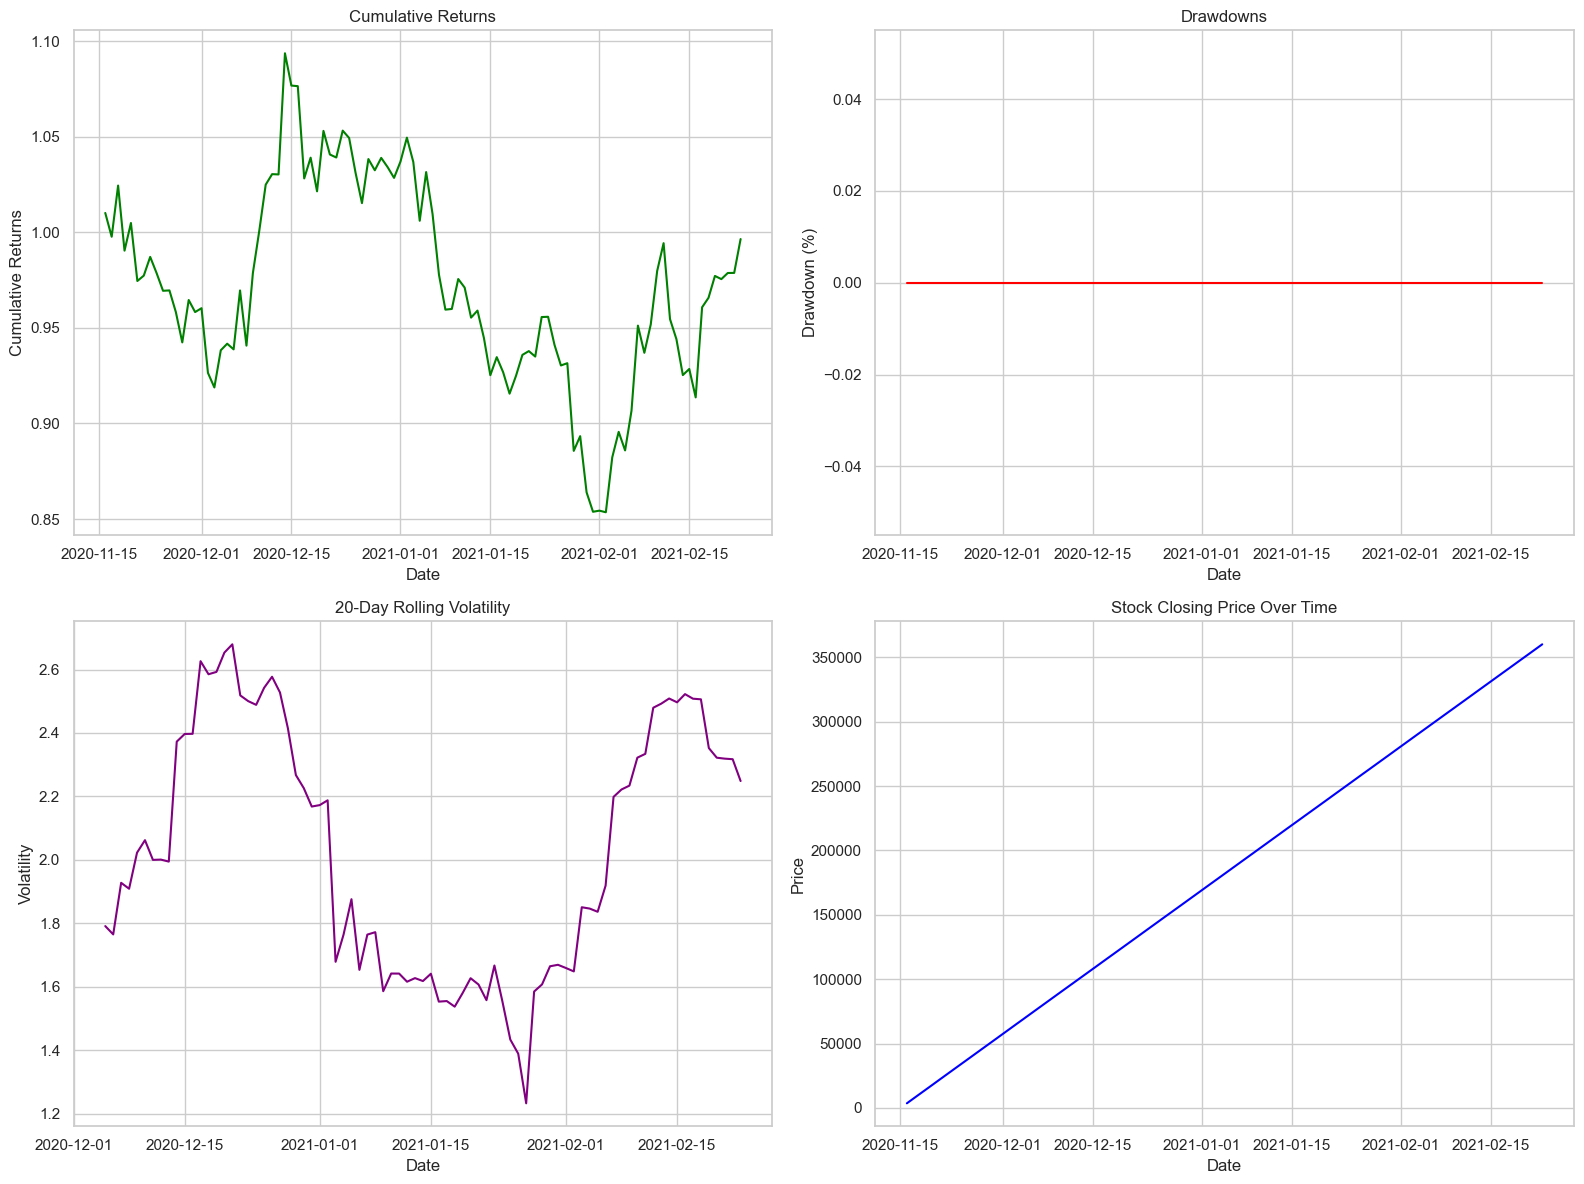

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming `yahoo` DataFrame is already prepared
# Prepare additional metrics for visualizations
yahoo['Cumulative_Returns'] = (1 + yahoo['Daily_Returns'] / 100).cumprod()
yahoo['Rolling_Max'] = yahoo['Close'].cummax()
yahoo['Drawdown'] = yahoo['Close'] / yahoo['Rolling_Max'] - 1
yahoo['Rolling_Volatility'] = yahoo['Daily_Returns'].rolling(window=20).std()

# Create a figure for the dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Cumulative Returns
sns.lineplot(data=yahoo, x='Date', y='Cumulative_Returns', ax=axes[0, 0], color='green')
axes[0, 0].set_title('Cumulative Returns')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Returns')

# Drawdowns
sns.lineplot(data=yahoo, x='Date', y='Drawdown', ax=axes[0, 1], color='red')
axes[0, 1].set_title('Drawdowns')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Drawdown (%)')

# Rolling Volatility
sns.lineplot(data=yahoo, x='Date', y='Rolling_Volatility', ax=axes[1, 0], color='purple')
axes[1, 0].set_title('20-Day Rolling Volatility')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Volatility')

# Stock Closing Price
sns.lineplot(data=yahoo, x='Date', y='Close', ax=axes[1, 1], color='blue')
axes[1, 1].set_title('Stock Closing Price Over Time')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Price')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


In [91]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample data preparation
data = {
    'Date': pd.date_range(start='2020-11-16', periods=100, freq='D'),
    'Close': np.cumsum(np.random.randn(100) * 10 + 3600),
    'Daily_Returns': np.random.randn(100) * 2,
    'Volume': np.random.randint(1e6, 1e7, 100)
}
yahoo = pd.DataFrame(data)

# Calculate additional metrics
yahoo['Cumulative_Returns'] = (1 + yahoo['Daily_Returns'] / 100).cumprod()
yahoo['Rolling_Max'] = yahoo['Close'].cummax()
yahoo['Drawdown'] = yahoo['Close'] / yahoo['Rolling_Max'] - 1
yahoo['Rolling_Volatility'] = yahoo['Daily_Returns'].rolling(window=20).std()

# Streamlit UI
st.title("Stock Performance Dashboard")

# Sidebar options
st.sidebar.header("Visualization Options")
show_cumulative_returns = st.sidebar.checkbox("Cumulative Returns", True)
show_drawdown = st.sidebar.checkbox("Drawdowns", True)
show_volatility = st.sidebar.checkbox("Rolling Volatility", True)
show_close_price = st.sidebar.checkbox("Stock Closing Price", True)

# Plotting graphs based on user selection
if show_cumulative_returns:
    st.subheader("Cumulative Returns")
    st.line_chart(yahoo[['Date', 'Cumulative_Returns']].set_index('Date'))

if show_drawdown:
    st.subheader("Drawdowns")
    st.line_chart(yahoo[['Date', 'Drawdown']].set_index('Date'))

if show_volatility:
    st.subheader("20-Day Rolling Volatility")
    st.line_chart(yahoo[['Date', 'Rolling_Volatility']].set_index('Date'))

if show_close_price:
    st.subheader("Stock Closing Price Over Time")
    st.line_chart(yahoo[['Date', 'Close']].set_index('Date'))
